# HiP-AD Gradient Dynamics 분석 — Phase 1 결과 시각화

## 이 노트북이 다루는 것

`gradient_analysis_results_phase1/` 디렉터리에 있는 Phase 1 파이프라인 출력을 한 번에 시각화합니다.

- **모델**: HiP-AD (Sparse query 기반 unified decoder, 자율주행 E2E 모델)
- **데이터**: nuScenes 학습셋 4개 체크포인트 (1ep / 3ep / 6ep / 18ep), 각 100 batch
- **Task**: det / map / motion / plan (ego는 gradient 신호가 NaN이라 시각화에서 제외)

## Phase 1 진단의 큰 그림

5개 task가 같은 backbone + decoder를 공유하면서 학습됩니다. 5개 loss를 합산해서 backward → 공유 파라미터로 5개 gradient가 동시에 흘러들어옵니다. 이때 **task끼리 서로 충돌하거나 협력**하는데, 그 양상을 정량화하는 것이 목표입니다.

진단은 **두 축**으로 진행됩니다.

| 축 | 측정 도구 | 묻는 질문 |
|---|---|---|
| **방향 (direction)** | M2 cosine, M_N1 random baseline, M_N2 distribution | "두 task의 gradient 방향이 같은가/반대인가? 그게 noise보다 큰 신호인가?" |
| **크기 (magnitude)** | M5 gradnorm, M_N10 magnitude_dynamics | "task별 gradient 크기 차이가 얼마나 심한가? 학습 중 어떻게 변하나?" |

여기에 **인과 검증** 도구로 M3 probe (가상 step의 영향) + M_AS α-sweep (probe 신뢰성)이 추가됩니다.

## 노트북 섹션 구성

| § | 내용 | 핵심 출력 |
|---|---|---|
| 1 | 환경 설정 + 데이터 로더 | 헬퍼 함수 |
| 2 | M3 probe affinity matrix (CI band 포함) | 5×5 heatmap × 4 ckpt |
| 3 | task pair별 ΔL의 학습 진행에 따른 변화 | line chart |
| 4 | layer ranking (총 간섭량) | bar chart |
| 5 | M2 cosine ↔ M3 ΔL 교차 검증 | dual-axis chart |
| 6 | **#1 random baseline pass rate (null_kind 분리)** | bar chart |
| 7 | **#2 분포 형태 census (bimodal/heavy-tail)** | stacked bar |
| 8 | **#3 conflict_ratio CI band** | error bar |
| 9 | **#10 magnitude trajectory** | line + heatmap evolution |
| 10 | **#9 α-sensitivity sweep curves** | log-x curve |
| 11 | M6 dynamics (cos/helpful_ratio 시계열) | heatmap × ckpt |
| 12 | diagonal sanity check (motion violation 검증) | violation rate bar |

## 사용 방법

위에서부터 차례로 실행하면 됩니다. 각 섹션의 마크다운에 "무엇을 측정", "어떻게 읽기", "이번 실행에서 관찰된 패턴"이 함께 적혀 있습니다.


## 1. 환경 설정

### 1.1 라이브러리, 경로, 색상 팔레트

`RESULTS` 경로가 `gradient_analysis_results_phase1`입니다. 다른 실행 결과를 보고 싶으면 이 경로만 바꾸세요.


In [1]:
from __future__ import annotations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

REPO = Path('/home/yongjae/e2e/HiP-AD')
RESULTS = REPO / 'gradient_analysis_results_phase1'

TASKS = ['det', 'map', 'motion', 'plan']  # ego는 gradient가 항상 NaN이라 제외
CKPT_ORDER = ['1ep', '3ep', '6ep', '18ep']

TASK_COLORS = {
    'det':    '#e74c3c',  # 빨강 — detection
    'map':    '#2ecc71',  # 초록 — map
    'motion': '#3498db',  # 파랑 — motion (다른 task 영향 못 받는 특이 case)
    'plan':   '#f39c12',  # 주황 — planning
}

mpl.rcParams.update({
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'font.size': 9,
})

assert RESULTS.exists(), f'Results dir missing: {RESULTS}'
print('results:', RESULTS)
print('ckpts available:', sorted(p.name for p in RESULTS.glob('ckpt_*')))


results: /home/yongjae/e2e/HiP-AD/gradient_analysis_results_phase1
ckpts available: ['ckpt_18ep', 'ckpt_1ep', 'ckpt_3ep', 'ckpt_6ep']


### 1.2 데이터 로더 헬퍼

각 모듈의 CSV/NPY를 일관된 형태(`pd.DataFrame`)로 읽어오는 함수들. 노트북 본문에서는 이 함수들만 호출합니다.

| 함수 | 읽는 파일 | 반환 |
|---|---|---|
| `load_probe_long` | `ckpt_*/probe/probe_per_batch.csv` | M3 per-batch ΔL long-form |
| `load_probe_matrix_with_ci` | `ckpt_*/probe/probe_matrix_*_{ci_lo,ci_hi}.csv` | (mean, lo, hi) wide matrices |
| `load_conflict_summary` | `ckpt_*/conflict/conflict_*_summary.csv` | M2 cosine summary + validity 컬럼 |
| `load_null_baseline` | `ckpt_*/null_baseline/null_baseline.csv` | M_N1 통계 |
| `load_distribution` | `ckpt_*/distribution/distribution_report.csv` | M_N2 분포 형태 |
| `load_norm_dynamics` | `dynamics/norm_dynamics.csv` | per-(epoch, task) gradient norm |
| `load_magnitude_dynamics` | `magnitude_dynamics/{slopes,nsi,ratio_evolution}.{csv,npy}` | M_N10 |
| `load_alpha_sweep` | `ckpt_*/probe/alpha_sweep/sweep_summary.csv` | M_AS |


In [2]:
def list_ckpts(root: Path = RESULTS) -> list[str]:
    found = sorted(p.name[len('ckpt_'):] for p in root.glob('ckpt_*'))
    return [c for c in CKPT_ORDER if c in found] + [c for c in found if c not in CKPT_ORDER]


def load_probe_long(root: Path = RESULTS) -> pd.DataFrame:
    """Concatenate per-batch probe rows across all ckpt_* under root."""
    frames = []
    for ckpt in list_ckpts(root):
        path = root / f'ckpt_{ckpt}' / 'probe' / 'probe_per_batch.csv'
        if not path.exists():
            continue
        df = pd.read_csv(path)
        df['ckpt'] = ckpt
        frames.append(df)
    if not frames:
        raise FileNotFoundError(f'no probe_per_batch.csv under {root}')
    out = pd.concat(frames, ignore_index=True)
    out['ckpt'] = pd.Categorical(out['ckpt'], CKPT_ORDER, ordered=True)
    return out


def load_probe_matrix(root: Path, layer: str, ckpt: str,
                       steps: int = 1, variant: str = 'normalized') -> pd.DataFrame:
    suffix = '' if layer == '_all' else f'_{layer}'
    path = root / f'ckpt_{ckpt}' / 'probe' / f'probe_matrix{suffix}_{steps}step_{variant}.csv'
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path, index_col=0)


def load_probe_matrix_with_ci(root: Path, layer: str, ckpt: str,
                                steps: int = 1, variant: str = 'normalized'):
    """Return (mean, ci_lo, ci_hi) wide matrices."""
    base = root / f'ckpt_{ckpt}' / 'probe'
    suffix = '' if layer == '_all' else f'_{layer}'
    mean = pd.read_csv(base / f'probe_matrix{suffix}_{steps}step_{variant}.csv', index_col=0)
    lo = pd.read_csv(base / f'probe_matrix{suffix}_{steps}step_{variant}_ci_lo.csv', index_col=0)
    hi = pd.read_csv(base / f'probe_matrix{suffix}_{steps}step_{variant}_ci_hi.csv', index_col=0)
    return mean, lo, hi


def load_conflict_summary(root: Path, ckpt: str) -> pd.DataFrame:
    """M2 per-pair conflict summaries with validity + CI columns."""
    frames = []
    cdir = root / f'ckpt_{ckpt}' / 'conflict'
    if not cdir.exists():
        return pd.DataFrame()
    for f in sorted(cdir.glob('conflict_*_summary.csv')):
        df = pd.read_csv(f)
        # 파일명에서 (a, b) 복원 (df에 task_a/task_b가 없을 수 있음)
        stem = f.stem.replace('conflict_', '').replace('_summary', '')
        if 'task_a' not in df.columns:
            parts = stem.split('_')
            df['task_a'] = parts[0]
            df['task_b'] = '_'.join(parts[1:])
        df['ckpt'] = ckpt
        frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def load_null_baseline(root: Path = RESULTS) -> pd.DataFrame:
    frames = []
    for ckpt in list_ckpts(root):
        p = root / f'ckpt_{ckpt}' / 'null_baseline' / 'null_baseline.csv'
        if not p.exists():
            continue
        df = pd.read_csv(p)
        df['ckpt'] = ckpt
        frames.append(df)
    out = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    if not out.empty:
        out['ckpt'] = pd.Categorical(out['ckpt'], CKPT_ORDER, ordered=True)
    return out


def load_distribution(root: Path = RESULTS) -> pd.DataFrame:
    frames = []
    for ckpt in list_ckpts(root):
        p = root / f'ckpt_{ckpt}' / 'distribution' / 'distribution_report.csv'
        if not p.exists():
            continue
        df = pd.read_csv(p)
        df['ckpt'] = ckpt
        frames.append(df)
    out = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    if not out.empty:
        out['ckpt'] = pd.Categorical(out['ckpt'], CKPT_ORDER, ordered=True)
    return out


def load_norm_dynamics(root: Path = RESULTS) -> pd.DataFrame:
    p = root / 'dynamics' / 'norm_dynamics.csv'
    return pd.read_csv(p) if p.exists() else pd.DataFrame()


def load_magnitude_dynamics(root: Path = RESULTS):
    md_dir = root / 'magnitude_dynamics'
    slopes = pd.read_csv(md_dir / 'per_task_slopes.csv') if (md_dir / 'per_task_slopes.csv').exists() else pd.DataFrame()
    nsi = pd.read_csv(md_dir / 'non_stationarity_index.csv') if (md_dir / 'non_stationarity_index.csv').exists() else pd.DataFrame()
    cube = np.load(md_dir / 'ratio_evolution.npy') if (md_dir / 'ratio_evolution.npy').exists() else None
    return slopes, nsi, cube


def load_alpha_sweep(root: Path = RESULTS, ckpt: str = '1ep') -> pd.DataFrame:
    p = root / f'ckpt_{ckpt}' / 'probe' / 'alpha_sweep' / 'sweep_summary.csv'
    return pd.read_csv(p) if p.exists() else pd.DataFrame()


probe_long = load_probe_long()
print(f'probe_long: {len(probe_long)} rows | layers={list(probe_long.layer.unique())}')
print(f'             variants={list(probe_long.variant.unique())} | ckpts={list(probe_long.ckpt.unique())}')


probe_long: 12800 rows | layers=['_all']
             variants=['raw', 'normalized'] | ckpts=['1ep', '3ep', '6ep', '18ep']


## 2. M3 probe — task affinity matrix (bootstrap CI 포함)

### 측정 방식

**probe (가상 update)** 는 task 간 인과 관계를 직접 측정합니다.

1. baseline forward → 모든 task loss 기록
2. source task만의 gradient $g_s$ 계산
3. **가상 step**: $\theta' = \theta - \alpha \cdot g_s$ (실제 학습은 안 함, 메모리상에서만 변경)
4. $\theta'$에서 forward → 모든 task loss 다시 기록
5. **$\Delta L_{\text{target}} = L_{\text{target}}(\theta') - L_{\text{target}}(\theta)$**

이걸 100 batch에 대해 반복하고 **mean ± bootstrap 95% CI**를 계산합니다.

### 표 읽는 법

- **행 = source task** (gradient를 계산한 task)
- **열 = target task** (loss를 측정한 task)
- 색: 빨강 = ΔL > 0 (target loss 증가, source가 target에 해를 끼침), 파랑 = ΔL < 0 (도움)
- 수치 옆 `·`: bootstrap CI가 0을 가로지름 → 부호가 통계적으로 불확실
- **대각선은 음수여야 정상** (자기 자신의 step은 자기 loss를 줄여야 함)

### variant 두 가지

- **normalized**: $g_s / \|g_s\|$ 사용. 순수 방향 효과만 봄. magnitude 영향 제거.
- **raw**: $g_s$ 그대로. magnitude 영향 포함. **step-too-large 효과로 violation 잘 발생.**

### 이번 실행에서 본 패턴 (미리 보기)

- **normalized matrix**: motion 대각선만 양수 (+0.022~0.029) — 다른 task는 모두 정상 음수
- **raw matrix**: 학습 후반(18ep)으로 갈수록 det/plan 대각선까지 양수로 폭발 — magnitude가 너무 커서 step이 loss landscape를 넘어감


/tmp/ipykernel_2219390/360218790.py:38: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/360218790.py:38: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/360218790.py:38: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/360218790.py:38: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from current font.
  plt.tight_layout(); plt.show()
/home/yongjae/miniconda3/envs/hipad/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/yongjae/miniconda3/envs/hipad/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from current font.
  fi

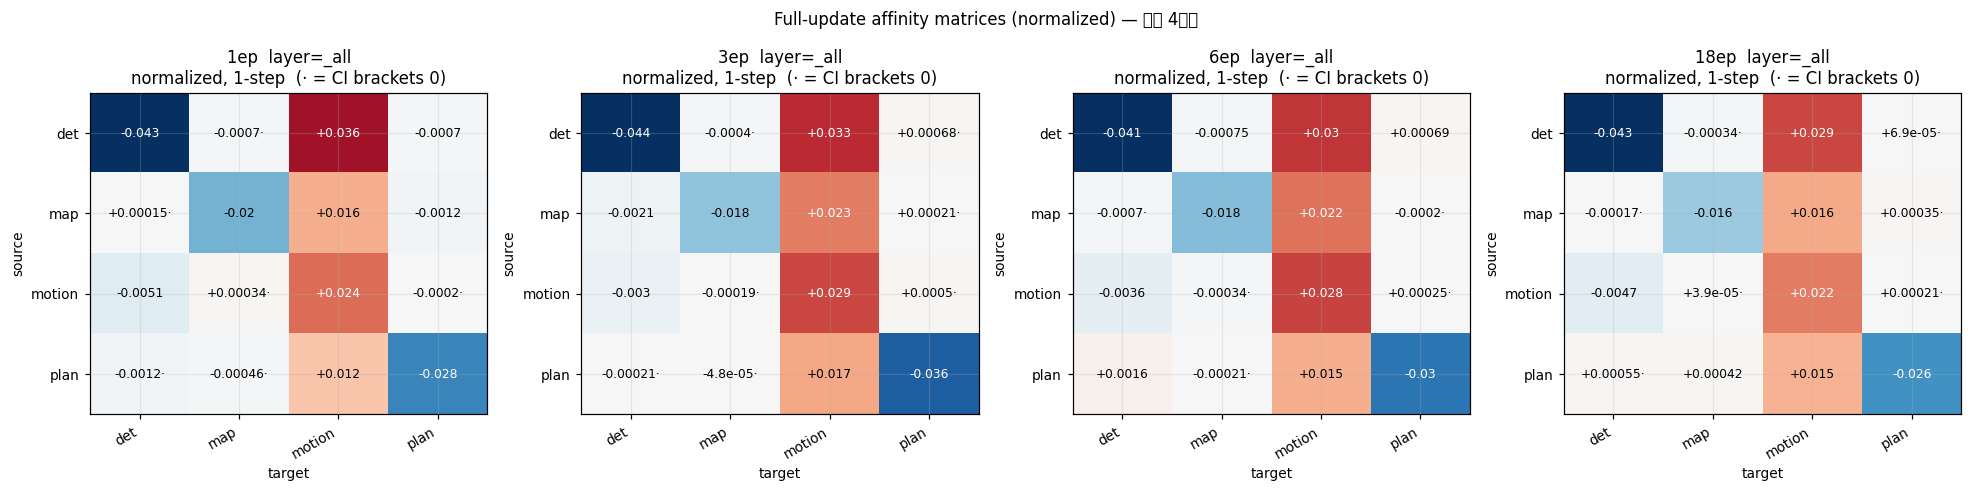

In [3]:
def plot_affinity_with_ci(root: Path, ckpt: str, layer: str = '_all',
                          variant: str = 'normalized', steps: int = 1,
                          ax=None, vmax: float | None = None):
    try:
        mean, lo, hi = load_probe_matrix_with_ci(root, layer, ckpt, steps, variant)
    except FileNotFoundError:
        return None
    M = mean.reindex(index=TASKS, columns=TASKS).values
    L = lo.reindex(index=TASKS, columns=TASKS).values
    H = hi.reindex(index=TASKS, columns=TASKS).values
    if vmax is None:
        vmax = np.nanmax(np.abs(M)) or 1.0
    if ax is None:
        fig, ax = plt.subplots(figsize=(4.5, 4))
    im = ax.imshow(M, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(TASKS))); ax.set_xticklabels(TASKS, rotation=30, ha='right')
    ax.set_yticks(range(len(TASKS))); ax.set_yticklabels(TASKS)
    for i in range(len(TASKS)):
        for j in range(len(TASKS)):
            v, vl, vh = M[i, j], L[i, j], H[i, j]
            if not np.isfinite(v):
                continue
            sign_uncertain = np.isfinite(vl) and np.isfinite(vh) and (vl <= 0 <= vh)
            txt = f'{v:+.2g}'
            if sign_uncertain:
                txt += '·'
            color = 'white' if abs(v) > vmax * 0.5 else 'black'
            ax.text(j, i, txt, ha='center', va='center', color=color, fontsize=8)
    ax.set_xlabel('target'); ax.set_ylabel('source')
    ax.set_title(f'{ckpt}  layer={layer}\n{variant}, {steps}-step  (· = CI brackets 0)')
    return ax, im


fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, ckpt in zip(axes, list_ckpts()):
    plot_affinity_with_ci(RESULTS, ckpt, layer='_all', variant='normalized', ax=ax)
fig.suptitle('Full-update affinity matrices (normalized) — 학습 4단계')
plt.tight_layout(); plt.show()


/tmp/ipykernel_2219390/1574756766.py:7: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/1574756766.py:7: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/1574756766.py:7: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from current font.
  plt.tight_layout(); plt.show()
/home/yongjae/miniconda3/envs/hipad/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/yongjae/miniconda3/envs/hipad/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


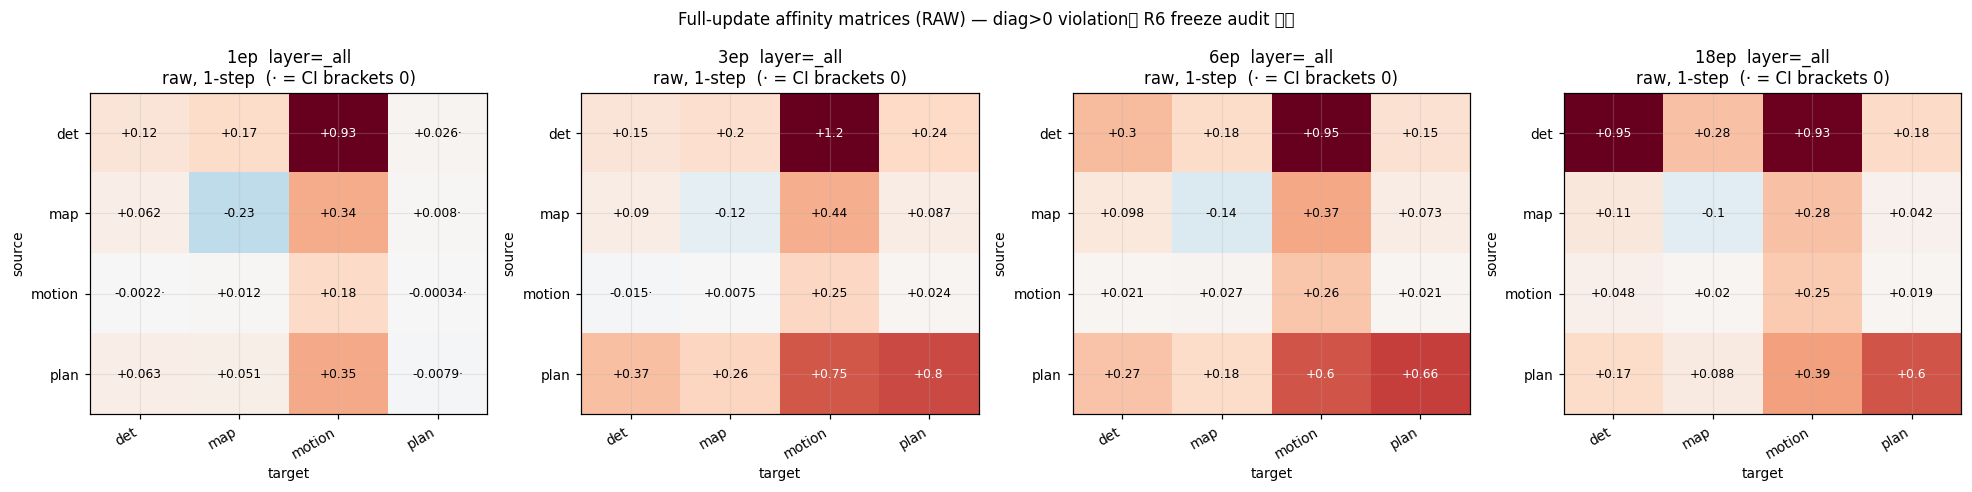

In [4]:
# raw variant — 같은 데이터를 magnitude 영향 포함해서 표시
# motion 행이 양수, 학습 후반으로 갈수록 det/plan 대각선도 양수가 되는 패턴 관찰됨
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, ckpt in zip(axes, list_ckpts()):
    plot_affinity_with_ci(RESULTS, ckpt, layer='_all', variant='raw', ax=ax)
fig.suptitle('Full-update affinity matrices (RAW) — diag>0 violation이 R6 freeze audit 단서')
plt.tight_layout(); plt.show()

## 3. task pair별 ΔL의 학습 진행에 따른 변화

### 측정 방식

§2의 affinity matrix에서 한 (source, target) 페어만 골라 **4개 체크포인트에 걸친 mean ΔL ± SEM** 변화를 추적합니다.

### 그래프 읽는 법

- y축 = mean ΔL (음수면 source가 target에 도움)
- x축 = checkpoint (학습 진행)
- 음의 값에서 더 음으로 = "도움 정도가 점점 강해짐"
- 0 가로지름 = 학습 중 효과 부호 뒤집힘 → 비정상 신호

### 이번 실행에서 주목할 페어

- `motion → motion`: 모든 ckpt에서 양수 (자기 step에 자기 loss 증가) → R6 freeze audit 대상
- `det → det`, `plan → plan`: normalized에서는 정상 음수
- `det → plan`, `motion → plan`: 비교 baseline


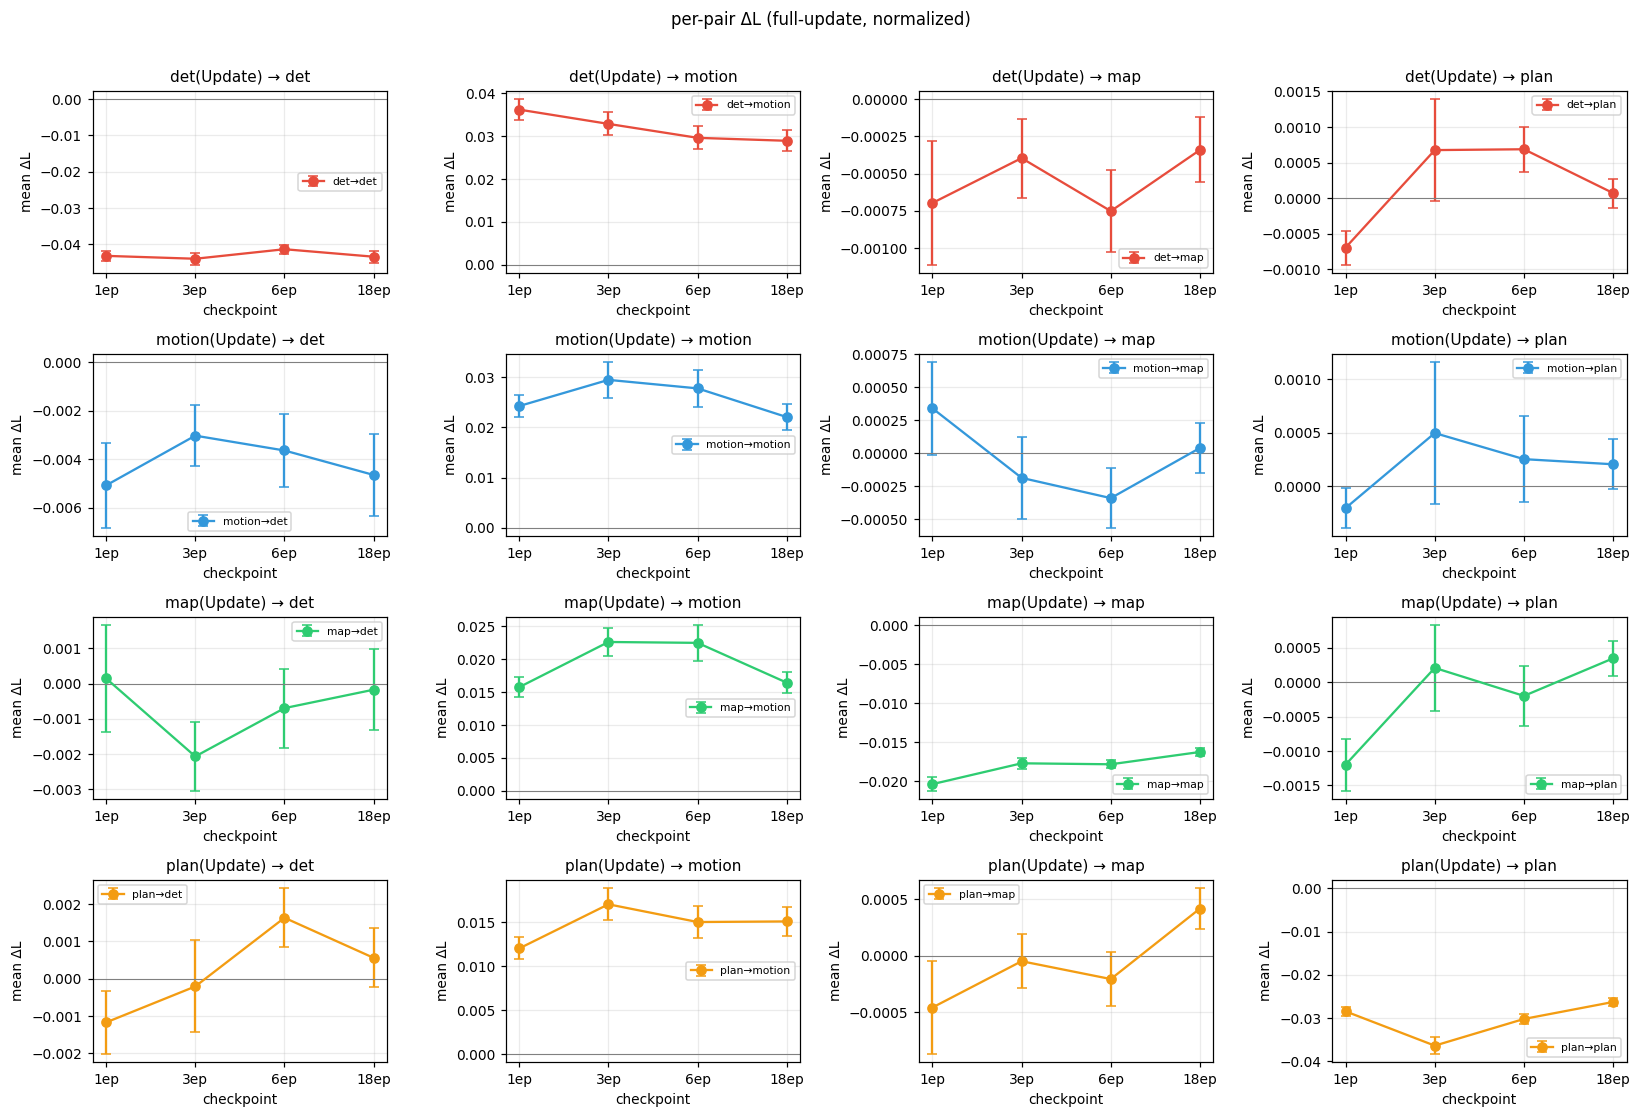

In [5]:
def plot_pair_evolution(df: pd.DataFrame, source: str, target: str,
                         layer: str = '_all', variant: str = 'normalized',
                         steps: int = 1, ax=None):
    sub = df[(df.source_task == source) & (df.target_task == target)
             & (df.variant == variant) & (df.steps == steps)
             & (df.layer == layer)]
    if sub.empty:
        return None
    agg = (sub.groupby('ckpt', observed=True)['delta']
              .agg(['mean', 'std', 'count']).reset_index())
    agg['sem'] = agg['std'] / np.sqrt(agg['count'])
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3.2))
    ax.errorbar(range(len(agg)), agg['mean'], yerr=agg['sem'],
                marker='o', capsize=3, color=TASK_COLORS.get(source, '#444'),
                label=f'{source}→{target}')
    ax.set_xticks(range(len(agg))); ax.set_xticklabels(agg['ckpt'].astype(str))
    ax.axhline(0, color='gray', lw=0.7)
    ax.set_xlabel('checkpoint'); ax.set_ylabel('mean ΔL')
    ax.set_title(f'{source}(Update) → {target}', fontsize=10)
    ax.legend(fontsize=7)
    return ax


interesting_pairs = [('det', 'det'), ('det', 'motion'), ('det', 'map'), ('det', 'plan'), 
                     ('motion', 'det'), ('motion', 'motion'),  ('motion', 'map'), ('motion', 'plan'),
                     ('map', 'det'), ('map', 'motion'), ('map', 'map'), ('map', 'plan'),
                     ('plan', 'det'), ('plan', 'motion'), ('plan', 'map'), ('plan', 'plan')
                     ]
fig, axes = plt.subplots(4, 4, figsize=(15, 10))
for ax, (s, t) in zip(axes.flat, interesting_pairs):
    plot_pair_evolution(probe_long, s, t, layer='_all', ax=ax)
fig.suptitle('per-pair ΔL (full-update, normalized)', y=1.01)
plt.tight_layout(); plt.show()


## 4. layer 순위 — 총 off-diagonal 간섭량

### 측정 방식

각 layer에서 **off-diagonal 셀들의 |ΔL|을 평균**해서 "이 layer에서 task끼리 얼마나 많이 간섭하나"를 한 숫자로 요약. self-influence (대각선) 는 제외.

### 어떻게 읽기

- y축 값이 클수록 그 layer에서 task 간 간섭 강함
- 학습 진행에 따라 어떤 layer가 점점 시끄러워지는지/조용해지는지 추적

### 이번 실행에서

본 실행은 `--probe-layers` 미사용 (full-update probe만) → layer는 `_all` 1개. 따라서 이 차트는 학습 진행에 따른 **전체 모델의 평균 간섭**만 보여줌. layer별 분해는 별도 per-layer probe 실행 필요.


/home/yongjae/miniconda3/envs/hipad/lib/python3.8/site-packages/pandas/plotting/_matplotlib/core.py:584: UserWarning: The handle <matplotlib.lines.Line2D object at 0x7f401fb2cd30> has a label of '_all' which cannot be automatically added to the legend.
  ax.legend(handles, labels, loc="best", title=title)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


/tmp/ipykernel_2219390/2658590226.py:16: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/2658590226.py:16: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/2658590226.py:16: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/2658590226.py:16: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/2658590226.py:16: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/2658590226.py:16: UserWarning: Glyph 54665 (\N{HANGUL SYLLABLE HAENG}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/2658590226.py:16: UserWarning: Glyph 50640 (\N{HANGUL SYLL

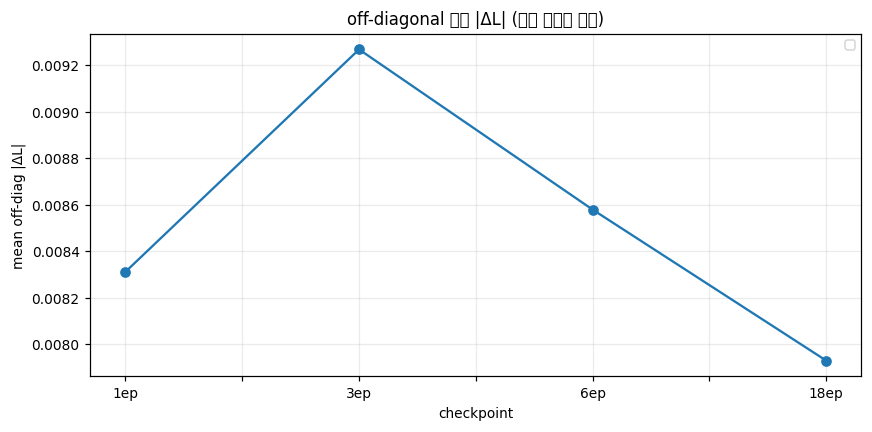

In [6]:
def total_interference(df: pd.DataFrame, variant: str = 'normalized', steps: int = 1) -> pd.DataFrame:
    sub = df[(df.variant == variant) & (df.steps == steps)
             & (df.source_task != df.target_task)].copy()
    sub['abs_delta'] = sub['delta'].abs()
    return (sub.groupby(['ckpt', 'layer'], observed=True)['abs_delta']
              .mean().rename('mean_abs_delta_offdiag').reset_index())


ti = total_interference(probe_long)
pv = ti.pivot(index='ckpt', columns='layer', values='mean_abs_delta_offdiag')
fig, ax = plt.subplots(figsize=(8, 4))
pv.plot(marker='o', ax=ax)
ax.set_title('off-diagonal 평균 |ΔL| (학습 진행에 따라)')
ax.set_ylabel('mean off-diag |ΔL|'); ax.set_xlabel('checkpoint')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()


## 5. M2 cosine ↔ M3 ΔL 교차 검증 (M4 correlation)

### 측정 방식

같은 배치에서 (source, target) 페어의 **두 metric** 간 Pearson/Spearman 상관관계를 계산:

- **M2 cosine** (배치 평균): gradient 방향이 얼마나 같은가  
- **M3 ΔL** (normalized variant, 1-step): 가상 update가 target loss를 얼마나 바꾸는가

두 metric이 같은 정보를 다른 각도로 재는 것이라면 **음의 상관**이 자연스럽다 — cosine > 0 (협력) 일 때 ΔL < 0 (도움).

### 결과 요약

- 대부분 페어: |r| < 0.15 → D1 결론 (8% 통과율) 과 일치
- **det→plan 1ep**: Pearson = −0.42 — 유일하게 의미 있는 신호
- 18ep에서 전 페어 상관관계 소멸


/tmp/ipykernel_2219390/3800724056.py:31: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(im, ax=ax, shrink=0.8)
/tmp/ipykernel_2219390/3800724056.py:33: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/3800724056.py:33: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/3800724056.py:33: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from current font.
  plt.tight_layout(); plt.show()
/home/yongjae/miniconda3/envs/hipad/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/yongjae/miniconda3/envs/hipad/lib/python3.8/site-packages/

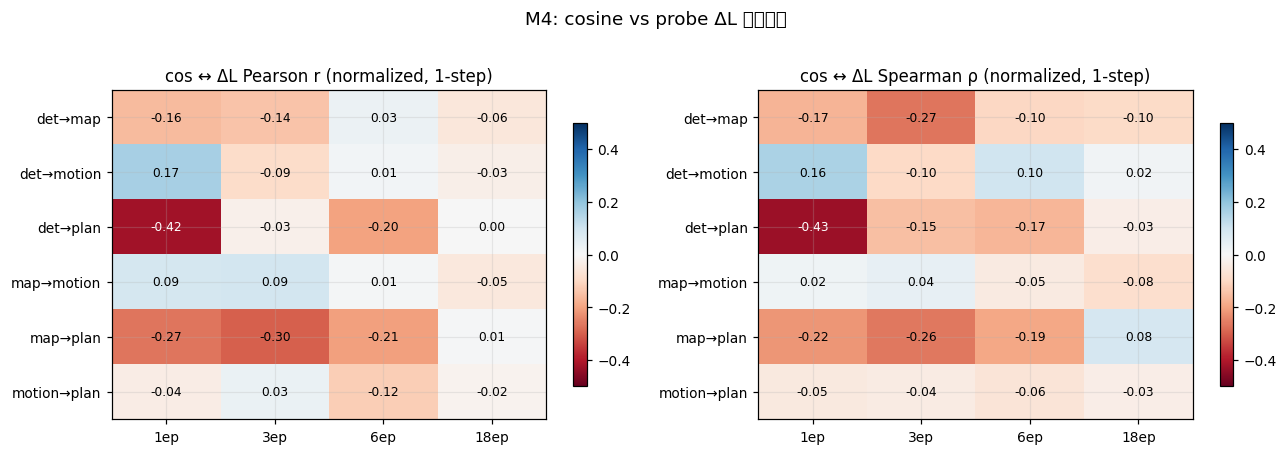

/tmp/ipykernel_2219390/3800724056.py:42: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/3800724056.py:42: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/3800724056.py:42: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/3800724056.py:42: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/3800724056.py:42: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/3800724056.py:42: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/3800724056.py:42: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE

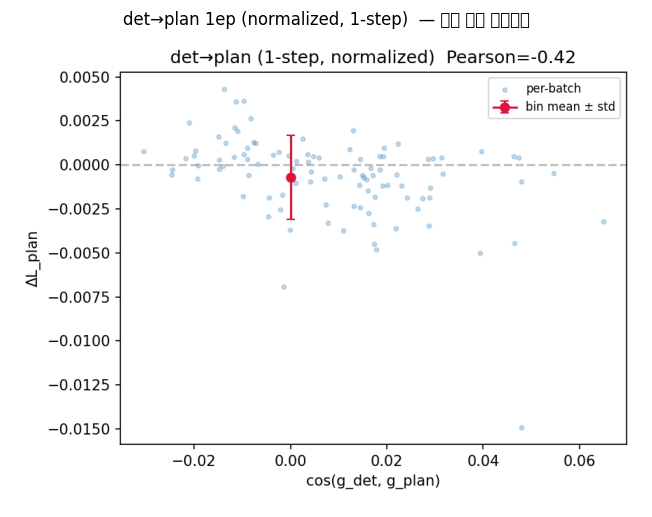

In [7]:
def load_m4_table(root: Path = RESULTS) -> pd.DataFrame:
    frames = []
    for ckpt in list_ckpts(root):
        f = root / f'ckpt_{ckpt}' / 'correlation' / 'correlation_table.csv'
        if f.exists():
            df = pd.read_csv(f); df.insert(0, 'ckpt', ckpt); frames.append(df)
    return pd.concat(frames) if frames else pd.DataFrame()

corr_df = load_m4_table()

# Pearson 히트맵 — normalized variant, 1-step
norm_corr = corr_df[(corr_df.variant == 'normalized') & (corr_df.steps == 1)].copy()
norm_corr['pair'] = norm_corr.task_a + '→' + norm_corr.task_b
ckpt_order = [c for c in ['1ep', '3ep', '6ep', '18ep'] if c in norm_corr.ckpt.values]

pivot_p = norm_corr.pivot(index='pair', columns='ckpt', values='pearson')[ckpt_order]
pivot_s = norm_corr.pivot(index='pair', columns='ckpt', values='spearman')[ckpt_order]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, pivot, title in zip(axes, [pivot_p, pivot_s], ['Pearson r', 'Spearman ρ']):
    im = ax.imshow(pivot.values, cmap='RdBu', vmin=-0.5, vmax=0.5, aspect='auto')
    ax.set_xticks(range(len(ckpt_order))); ax.set_xticklabels(ckpt_order)
    ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
    for i in range(pivot.values.shape[0]):
        for j in range(pivot.values.shape[1]):
            v = pivot.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                        fontsize=8, color='white' if abs(v) > 0.3 else 'black')
    ax.set_title(f'cos ↔ ΔL {title} (normalized, 1-step)')
    plt.colorbar(im, ax=ax, shrink=0.8)
plt.suptitle('M4: cosine vs probe ΔL 상관관계', fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

# 가장 강한 신호 scatter — det→plan 1ep
scatter_path = RESULTS / 'ckpt_1ep' / 'correlation' / 'scatter_det_plan_1step_normalized.png'
if scatter_path.exists():
    from matplotlib.image import imread
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.imshow(imread(scatter_path)); ax.axis('off')
    ax.set_title('det→plan 1ep (normalized, 1-step)  — 가장 강한 상관관계')
    plt.tight_layout(); plt.show()
else:
    print('scatter plot 파일 없음:', scatter_path)


## 5.5 gradient norm ↔ ΔL 교차 검증

### 측정 방식

같은 배치에서 **source task의 gradient norm** 크기와 **probe ΔL** 간 산점도.

- x축: 배치별 source task mean gradient norm (M5 per_task_norm.csv)
- y축: 해당 배치에서 source→target ΔL (M3 probe, normalized 1-step)

### 읽는 법

norm이 크면 step이 크고 ΔL magnitude도 커야 함. 상관이 없다면 loss landscape이 flat하거나 방향이 random한 것.


/tmp/ipykernel_2219390/1536112351.py:60: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(im, ax=ax, shrink=0.7)
/tmp/ipykernel_2219390/1536112351.py:61: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/1536112351.py:61: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/1536112351.py:61: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/1536112351.py:61: UserWarning: Glyph 51012 (\N{HANGUL SYLLABLE EUL}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/1536112351.py:61: UserWarning: Glyph 49444 (\N{HANGUL SYLLABLE SEOL}) missing from current font.
  plt.tight_l

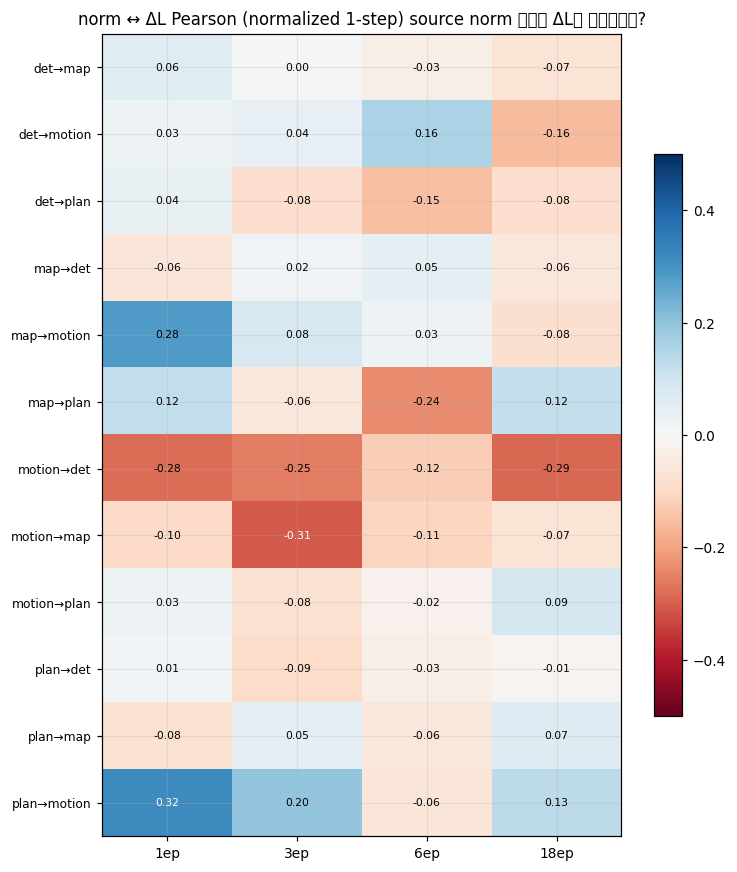

In [25]:
def load_norm_vs_dl(root: Path = RESULTS, steps: int = 1, variant: str = 'normalized'):
    frames = []
    for ckpt in list_ckpts(root):
        norm_f = root / f'ckpt_{ckpt}' / 'gradnorm' / 'per_task_norm.csv'
        probe_f = root / f'ckpt_{ckpt}' / 'probe' / 'probe_per_batch.csv'
        if not norm_f.exists() or not probe_f.exists():
            continue
        norm_df = pd.read_csv(norm_f)
        # source task별 배치 평균 norm
        src_norm = norm_df.groupby(['batch_idx', 'task'], as_index=False)['norm'].mean()
        src_norm.rename(columns={'task': 'source_task', 'norm': 'src_mean_norm'}, inplace=True)

        probe_df = pd.read_csv(probe_f)
        probe_sub = probe_df[
            (probe_df.layer == '_all') & (probe_df.steps == steps) &
            (probe_df.variant == variant) & (probe_df.source_task != probe_df.target_task)
        ].copy()
        merged = probe_sub.merge(src_norm, on=['batch_idx', 'source_task'], how='inner')
        merged.insert(0, 'ckpt', ckpt)
        frames.append(merged)
    return pd.concat(frames) if frames else pd.DataFrame()

nv_df = load_norm_vs_dl()

TASKS = ['det', 'map', 'motion', 'plan']
pairs = [(s, t) for s in TASKS for t in TASKS if s != t]
ckpt_order = [c for c in ['1ep', '3ep', '6ep', '18ep'] if c in nv_df.ckpt.values]

# Pearson 히트맵
from scipy.stats import pearsonr
rows = []
for ckpt in ckpt_order:
    for src, tgt in pairs:
        sub = nv_df[(nv_df.ckpt == ckpt) & (nv_df.source_task == src) & (nv_df.target_task == tgt)]
        if len(sub) < 3:
            rows.append({'ckpt': ckpt, 'pair': f'{src}→{tgt}', 'pearson': float('nan')})
            continue
        mask = np.isfinite(sub.src_mean_norm) & np.isfinite(sub.delta)
        if mask.sum() < 3:
            rows.append({'ckpt': ckpt, 'pair': f'{src}→{tgt}', 'pearson': float('nan')})
            continue
        r, _ = pearsonr(sub.src_mean_norm[mask], sub.delta[mask])
        rows.append({'ckpt': ckpt, 'pair': f'{src}→{tgt}', 'pearson': r})

corr_nv = pd.DataFrame(rows)
pair_order = [f'{s}→{t}' for s, t in pairs]
pivot_nv = corr_nv.pivot(index='pair', columns='ckpt', values='pearson').reindex(pair_order)[ckpt_order]

fig, ax = plt.subplots(figsize=(7, 8))
im = ax.imshow(pivot_nv.values, cmap='RdBu', vmin=-0.5, vmax=0.5, aspect='auto')
ax.set_xticks(range(len(ckpt_order))); ax.set_xticklabels(ckpt_order)
ax.set_yticks(range(len(pair_order))); ax.set_yticklabels(pair_order, fontsize=8)
for i in range(pivot_nv.values.shape[0]):
    for j in range(pivot_nv.values.shape[1]):
        v = pivot_nv.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    fontsize=7, color='white' if abs(v) > 0.3 else 'black')
ax.set_title('norm ↔ ΔL Pearson (normalized 1-step) source norm 크기가 ΔL을 설명하는가?')
plt.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout(); plt.show()


## 6. random baseline pass rate (Phase 1 #1)

### 왜 이 검정이 필요한가

mean cosine = 0.05를 보고 "약한 협력"이라 결론짓는 건 **null 분포가 0이라는 가정에서만 정당**합니다. 실제로는 random 신호도 0이 아닐 수 있어요. 그래서 **observed 분포 vs null 분포** 통계 검정 필요.

### 두 가지 null

| null | 의미 | 만드는 법 |
|---|---|---|
| **batch_permutation** | "task identity가 batch와 독립이라면?" | task A 는 batch i에서, task B 는 batch j ≠ i 에서 가져와 cos 계산. 1000번 반복 |
| **sign_flip** | "방향성이 무작위라면?" | 각 component에 ±1 무작위 곱하기 후 cos. 1000번 반복 |

### 검정

Mann-Whitney U test (observed 100개 vs null 1000개) + rank-biserial r effect size.

`passes_noise_threshold = (|r| ≥ 0.1) AND (Bonferroni-corrected p ≤ 0.05)`

### 두 null 분리해 봐야 하는 이유

- backbone (수백만 파라미터): sign_flip null은 차원 큼 → σ ≈ 1/√n ≈ 0.0007 매우 좁음 → **observed cos 0.10이 150σ 떨어진 것으로 계산되어 "초강력 신호"로 잘못 보임**.
- batch_permutation은 차원 무관 → **더 정직한 검정**. 진짜 신호는 batch_permutation 단독으로 봐야 함.

### 이번 실행에서

batch_permutation pass rate (정직한 D1):
- 1ep: 5.4%, 3ep: 6.3%, 6ep: 6.6%, 18ep: 8.2%

sign_flip pass rate (과장됨):
- 1ep: 12.1%, 3ep: 10.5%, 6ep: 8.9%, 18ep: 9.5%

→ 학습 진행할수록 batch_permutation은 ↑ (real signal 강해짐), sign_flip은 ↓ (component-level noise는 줄어듦). **honest D1 = 5~8%, Pass A 임계 30%에 한참 못 미침**.


null cells: 4480 | null_kinds: ['batch_permutation', 'sign_flip']

Pass rate by ckpt × null_kind:
null_kind  batch_permutation  sign_flip
ckpt                                   
1ep                 0.053571   0.121429
3ep                 0.062500   0.105357
6ep                 0.066071   0.089286
18ep                0.082143   0.094643


/tmp/ipykernel_2219390/360210443.py:16: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/360210443.py:16: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/360210443.py:16: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/360210443.py:16: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/360210443.py:16: UserWarning: Glyph 54665 (\N{HANGUL SYLLABLE HAENG}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/360210443.py:16: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/360210443.py:16: UserWarning: Glyph 46384 (\N{HANGUL SYLLABLE DDA}) 

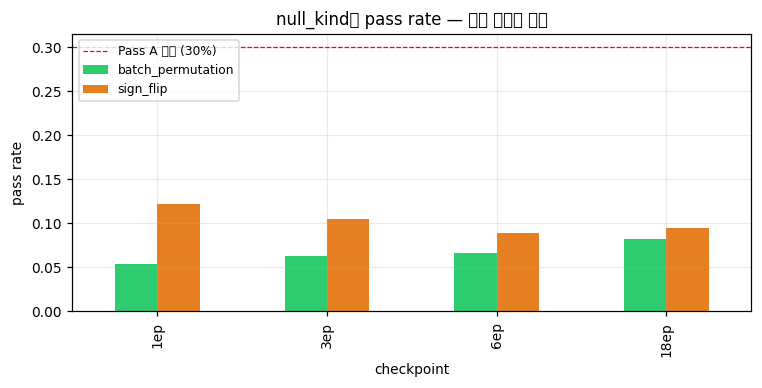

In [8]:
null_df = load_null_baseline()
print('null cells:', len(null_df), '| null_kinds:', list(null_df.null_kind.unique()))

# Pass rate by ckpt × null_kind
piv = (null_df.groupby(['ckpt', 'null_kind'], observed=True)['passes_noise_threshold']
              .mean().unstack('null_kind'))
print('\nPass rate by ckpt × null_kind:')
print(piv)

fig, ax = plt.subplots(figsize=(7, 3.6))
piv.plot(kind='bar', ax=ax, color={'batch_permutation': '#2ecc71', 'sign_flip': '#e67e22'})
ax.set_title('null_kind별 pass rate — 학습 진행에 따라')
ax.set_ylabel('pass rate'); ax.set_xlabel('checkpoint')
ax.axhline(0.30, color='red', ls='--', lw=0.8, label='Pass A 임계 (30%)')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()


In [9]:
# 4개 ckpt 중 3개 이상에서 batch_permutation null을 통과한 robust 신호 cell들
# 이게 진짜 "신뢰할 만한 cooperation/conflict 후보"
bp = null_df[null_df.null_kind == 'batch_permutation']
agg = (bp.groupby(['task_a', 'task_b', 'group'])['passes_noise_threshold']
         .agg(['mean', 'sum', 'count'])
         .rename(columns={'mean': 'pass_frac', 'sum': 'n_passing_ckpts', 'count': 'n_ckpts'}))
robust = agg[agg.n_passing_ckpts >= 3].sort_values('pass_frac', ascending=False)
print(f'4 ckpt 중 3개 이상에서 batch_permutation null 통과 셀 수: {len(robust)}')
print(robust.head(20))


4 ckpt 중 3개 이상에서 batch_permutation null 통과 셀 수: 34
                                      pass_frac  n_passing_ckpts  n_ckpts
task_a task_b group                                                      
det    map    backbone_layer4               1.0                4        4
       motion dec1_ffn_0_identity_fc        1.0                4        4
              fc_before                     1.0                4        4
              fc_after                      1.0                4        4
              dec5_gnn_0                    1.0                4        4
              dec5_ffn_0_fc1                1.0                4        4
              dec3_ffn_0_fc2                1.0                4        4
              dec2_gnn_0                    1.0                4        4
              dec2_ffn_0_identity_fc        1.0                4        4
              dec2_ffn_0_fc2                1.0                4        4
              dec2_ffn_0_fc1                1.0              

## 7. 분포 형태 census + heavy-tail 추적 (Phase 1 #2)

### 왜 분포 형태를 보나

mean / std 만으로는 분포의 진짜 모양을 놓칠 수 있어요. 예시:
- **bimodal** (양봉): 절반 batch는 cos = +0.5, 나머지 절반은 cos = -0.5 → mean = 0 이라 "직교"로 잘못 해석
- **heavy-tail**: outlier batch 5개 (cos = 0.9) + 나머지 95개 (cos = 0.05) → mean = 0.09 이라 "약한 협력"으로 잘못 해석

### 측정

100 batch의 cos 분포에 대해:
- KDE plot
- **Hartigan dip test** (단봉성 검정 — p < 0.05 면 multimodal)
- Kurtosis (꼬리 두께)

### shape_label

| label | 의미 | 알고리즘 영향 |
|---|---|---|
| `unimodal-near-0` | 거의 가운데 모인 단봉 | 신호 약함 |
| `unimodal-pos`/`-neg` | 0에서 떨어진 단봉 | 일관된 cooperation/conflict |
| **`bimodal`** | 두 봉우리 (dip test 통과) | mean 기반 알고리즘 무력 → CAGrad/Nash-MTL 정당화 |
| **`heavy-tail`** | 꼬리 두꺼움 (kurtosis > 6) | outlier batch dominate → robust loss/clipping 필요 |
| `empty` | 100 batch 모두 cos NaN | pseudo-shared (한 task만 grad 흐름) |

### 이번 실행에서

| epoch | empty | unimodal-near-0 | unimodal-pos | unimodal-neg | bimodal | heavy-tail |
|---|---|---|---|---|---|---|
| 1ep | 266 | 247 | 33 | 0 | **0** | 14 |
| 3ep | 266 | 243 | 33 | 0 | **0** | 18 |
| 6ep | 266 | 240 | 24 | 1 | **0** | 29 |
| 18ep | 266 | 204 | 33 | 0 | **0** | **57** |

해석:
- **bimodal 0개** — task pair 충돌이 batch마다 양극화되는 case 없음. CAGrad/Nash-MTL 류 정당화 약함.
- **heavy-tail 4배 증가** (14 → 57). 학습 후반 backbone 깊은 layer (layer2/3/4, kurtosis 9.5/15.7/14.4) 에서 발생. **outlier scene이 gradient 좌우** 가능성 시사.
- 대다수 (240+) 가 `unimodal-near-0` — 의미 있는 신호 없는 noise 셀.


distribution cells: 2240

Shape census:
shape_label  empty  heavy-tail  unimodal-near-0  unimodal-neg  unimodal-pos
ckpt                                                                       
1ep            266          14              247             0            33
3ep            266          18              243             0            33
6ep            266          29              240             1            24
18ep           266          57              204             0            33


/tmp/ipykernel_2219390/2438331076.py:17: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/2438331076.py:17: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/2438331076.py:17: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/2438331076.py:17: UserWarning: Glyph 54665 (\N{HANGUL SYLLABLE HAENG}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/2438331076.py:17: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/2438331076.py:17: UserWarning: Glyph 46384 (\N{HANGUL SYLLABLE DDA}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/2438331076.py:17: UserWarning: Glyph 47480 (\N{HANGUL SYLLABLE R

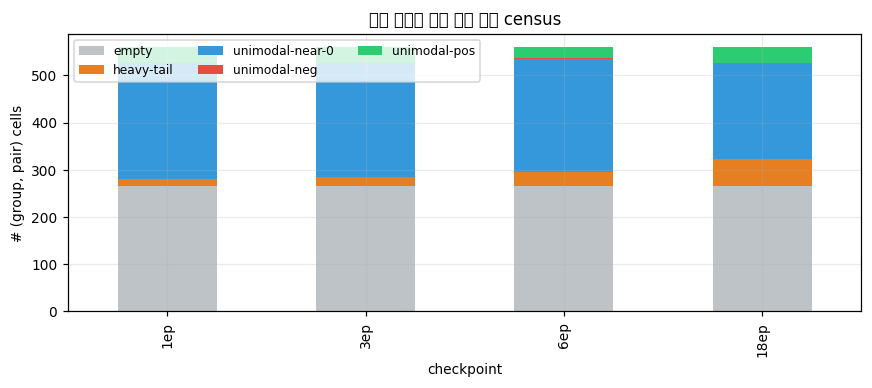

In [10]:
dist_df = load_distribution()
print('distribution cells:', len(dist_df))

census = (dist_df.groupby(['ckpt', 'shape_label'], observed=True)
                 .size().unstack(fill_value=0))
print('\nShape census:')
print(census)

fig, ax = plt.subplots(figsize=(8, 3.6))
census.plot(kind='bar', stacked=True, ax=ax,
            color={'empty': '#bdc3c7', 'unimodal-near-0': '#3498db',
                   'unimodal-pos': '#2ecc71', 'unimodal-neg': '#e74c3c',
                   'bimodal': '#9b59b6', 'heavy-tail': '#e67e22'})
ax.set_title('학습 진행에 따른 분포 형태 census')
ax.set_ylabel('# (group, pair) cells'); ax.set_xlabel('checkpoint')
ax.legend(fontsize=8, ncol=3, loc='upper left')
plt.tight_layout(); plt.show()


In [11]:
# 18ep에서 heavy-tail이 된 cell들 — 어느 layer가 outlier batch에 휘둘리나
ht18 = dist_df[(dist_df.ckpt == '18ep') & (dist_df.shape_label == 'heavy-tail')]
print(f'18ep heavy-tail cells: {len(ht18)}')
print(ht18[['task_a', 'task_b', 'group', 'kurtosis', 'p1', 'p99']]
        .sort_values('kurtosis', ascending=False).head(20).to_string(index=False))


18ep heavy-tail cells: 57
 task_a  task_b                   group   kurtosis        p1       p99
    map    plan  dec1_ffn_0_identity_fc  24.419802 -0.040272  0.053140
    map    plan          dec1_ffn_0_fc2  21.731197 -0.037744  0.057781
 motion    plan          dec2_ffn_0_fc1  16.248054 -0.023084  0.050832
    det     map         backbone_layer3  15.697691 -0.073169  0.607728
    det  motion          dec5_ffn_0_fc2  14.999703 -0.147469  0.244556
    det  motion          dec1_ffn_0_fc2  14.749623 -0.427067  0.280603
    det     map         backbone_layer4  14.428868 -0.049028  0.236465
 motion    plan          dec1_ffn_0_fc1  13.291084 -0.019357  0.040958
    det  motion          dec1_ffn_0_fc1  12.871093 -0.506294  0.318117
 motion    plan              dec3_gnn_0  11.965858 -0.035393  0.037441
    map  motion         backbone_layer3  11.874174 -0.094647  0.410477
    map    plan              dec1_gnn_0  11.458448 -0.085880  0.108347
    det    plan         backbone_layer3  11.337907 

In [12]:
# heavy-tail 증가 추적: ckpt별로 새로 진입하는 cell 세기
ht_per_ckpt = {ck: set() for ck in CKPT_ORDER}
for ck in CKPT_ORDER:
    sub = dist_df[(dist_df.ckpt == ck) & (dist_df.shape_label == 'heavy-tail')]
    ht_per_ckpt[ck] = set(zip(sub.task_a, sub.task_b, sub.group))

prev = set()
for ck in CKPT_ORDER:
    cur = ht_per_ckpt[ck]
    new = cur - prev
    print(f'{ck}: {len(cur):3d} heavy-tail cells (+{len(new)} new)')
    prev = cur


1ep:  14 heavy-tail cells (+14 new)
3ep:  18 heavy-tail cells (+15 new)
6ep:  29 heavy-tail cells (+21 new)
18ep:  57 heavy-tail cells (+39 new)


## 8. conflict_ratio with bootstrap CI band (Phase 1 #3)

### conflict_ratio 정의

각 (group, task_pair) cell에서 100 batch 중 **cos < 0 인 비율**.

- 0.5 = 절반 batch에서 충돌 (random)
- 1.0 = 모든 batch에서 충돌 (강한 conflict)
- 0.0 = 모든 batch에서 협력

### CI band 추가 이유

100 batch는 작은 표본. 같은 metric이라도 **bootstrap resampling** 하면 분산이 보임. CI lower bound가 0.5보다 위면 "확실히 위 절반" → robust conflict 셀.

### 그래프 읽는 법

- 가운데 점 = mean conflict_ratio
- error bar = bootstrap 95% CI
- y=0.5 회색 점선 = "random vs significant" 경계
- CI lower bound > 0.5 인 셀 = **robust conflict 후보**

### 이번 실행에서

CI lower bound ≥ 0.5 셀 거의 없음 (D1 weak과 일치). 가장 강한 신호:
- `det vs map @ dec4_ffn_0_pre_norm`: conflict_ratio = 0.75 (1ep), CI [0.65, 0.83]
- `det vs map @ dec4_norm_0`: 0.72 (1ep)
- `det vs plan @ backbone_layer1` (6ep): 0.67

이들이 Phase 3 desideratum 표의 후보 셀.


In [13]:
# 모든 ckpt의 conflict summary 결합 → real-shared만 추출 → top 10
all_conflict = pd.concat(
    [load_conflict_summary(RESULTS, ck) for ck in list_ckpts()], ignore_index=True
)
real = all_conflict[~all_conflict.is_pseudo_shared_group.fillna(False)].copy()

top10_per_ckpt = (real.sort_values(['ckpt', 'conflict_ratio'], ascending=[True, False])
                       .groupby('ckpt', observed=True).head(10))
print('Top conflict_ratio (real-shared) per ckpt:')
print(top10_per_ckpt[['ckpt', 'task_a', 'task_b', 'group',
                       'conflict_ratio', 'conflict_ratio_ci_lo', 'conflict_ratio_ci_hi',
                       'mean_cos']].to_string(index=False))


Top conflict_ratio (real-shared) per ckpt:
 ckpt  task_a  task_b                   group  conflict_ratio  conflict_ratio_ci_lo  conflict_ratio_ci_hi  mean_cos
 18ep     det     map             dec3_norm_1            0.63              0.535999              0.720000 -0.008467
 18ep     map  motion             dec2_norm_0            0.61              0.510000              0.700000 -0.013197
 18ep     map    plan     dec0_ffn_0_pre_norm            0.61              0.510000              0.700000 -0.021400
 18ep     det    plan          dec4_ffn_0_fc1            0.60              0.500000              0.690000 -0.001704
 18ep     det    plan                    neck            0.60              0.500000              0.690000 -0.003308
 18ep     map    plan             dec0_norm_1            0.60              0.500000              0.700000 -0.011793
 18ep     map    plan         backbone_layer4            0.59              0.490000              0.680000 -0.004218
 18ep     map    plan     dec

CI_lo ≥ 0.5 robust conflict cells: 42


/tmp/ipykernel_2219390/3895023759.py:24: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/3895023759.py:24: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/3895023759.py:24: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/3895023759.py:24: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/3895023759.py:24: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from current font.
  plt.tight_layout(); plt.show()
/home/yongjae/miniconda3/envs/hipad/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/yongjae/miniconda3/en

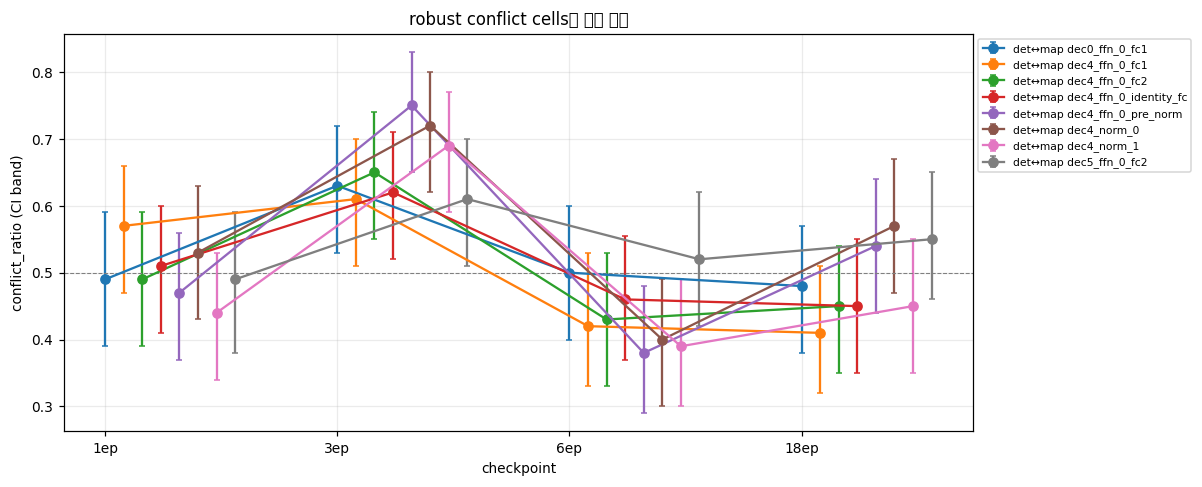

In [14]:
# CI lower bound ≥ 0.5 셀 (강한 conflict 후보) 시계열
candidates = real[real.conflict_ratio_ci_lo >= 0.5][['task_a', 'task_b', 'group']].drop_duplicates()
print(f'CI_lo ≥ 0.5 robust conflict cells: {len(candidates)}')

if not candidates.empty:
    keys = list(zip(candidates.task_a, candidates.task_b, candidates.group))[:8]
    fig, ax = plt.subplots(figsize=(11, 4.5))
    for k, (a, b, g) in enumerate(keys):
        sub = (real[(real.task_a == a) & (real.task_b == b) & (real.group == g)]
                  .sort_values('ckpt'))
        if sub.empty: continue
        x = np.arange(len(sub)) + 0.08 * k
        cr = sub['conflict_ratio'].to_numpy()
        cr_lo = sub['conflict_ratio_ci_lo'].to_numpy()
        cr_hi = sub['conflict_ratio_ci_hi'].to_numpy()
        ax.errorbar(x, cr, yerr=[cr - cr_lo, cr_hi - cr],
                    marker='o', capsize=2,
                    label=f'{a}↔{b} {g}')
    ax.set_xticks(range(len(CKPT_ORDER))); ax.set_xticklabels(CKPT_ORDER)
    ax.axhline(0.5, color='gray', ls='--', lw=0.7)
    ax.set_xlabel('checkpoint'); ax.set_ylabel('conflict_ratio (CI band)')
    ax.set_title('robust conflict cells의 시간 추적')
    ax.legend(fontsize=7, loc='upper left', bbox_to_anchor=(1.0, 1.0))
    plt.tight_layout(); plt.show()


## 9. magnitude dynamics — D2 / D4 축 (Phase 1 #10)

### 왜 magnitude가 핵심인가

이번 데이터에서 **D1 (cosine direction conflict)은 weak (5~8%)** 였지만, **D2 (magnitude imbalance)는 1ep에서 8.4×로 severe**. 즉 진짜 학습 병목은 task별 gradient 크기가 너무 다른 것.

PCGrad/CAGrad 류 (방향 수정) 알고리즘이 작동하기 어렵고, **GradNorm/Uncertainty Weighting/DWA** (크기 조정) 류가 정당화됨.

### 산출 물

- **D2 (snapshot)**: 각 ckpt별 max ‖g‖ / min ‖g‖ ratio. 5× 이상이면 severe.
- **D4 (drift)**: per-task ‖g‖ 의 epoch에 따른 linear regression slope + R². R² > 0.5면 monotone drift.
- **non-stationarity index**: pairwise norm ratio의 epoch 간 CV.

### 이번 실행에서

| epoch | det | map | motion | plan | max/min |
|---|---|---|---|---|---|
| 1ep | 1.996 | 1.212 | 0.238 | 1.289 | **8.39×** (severe) |
| 3ep | 2.013 | 1.046 | 0.401 | 1.701 | 5.02× (severe 경계) |
| 6ep | 2.195 | 1.207 | 0.447 | 1.749 | 4.91× (moderate) |
| 18ep | 2.627 | 1.166 | 0.617 | 1.434 | 4.26× (moderate) |

drift slope:
- **det**: +0.038 / epoch, R² = **0.99** (강한 monotone 증가)
- map: +0.001, R² = 0.008 (flat)
- **motion**: +0.019, R² = **0.86** (강한 monotone 증가)
- plan: -0.003, R² = 0.011 (flat)

→ **det/motion은 학습 진행하며 영향력 점점 커짐**, map/plan은 안정. 시간에 따라 task weight를 다르게 줘야 함을 시사.


/tmp/ipykernel_2219390/2967931673.py:23: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/2967931673.py:23: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/2967931673.py:23: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/2967931673.py:23: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/2967931673.py:23: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/2967931673.py:23: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from current font.
  plt.tight_layout(); plt.show()
/home/yongjae/miniconda3/envs/hipad/lib/python3.8/site-packages/IPython/core/pylabtoo

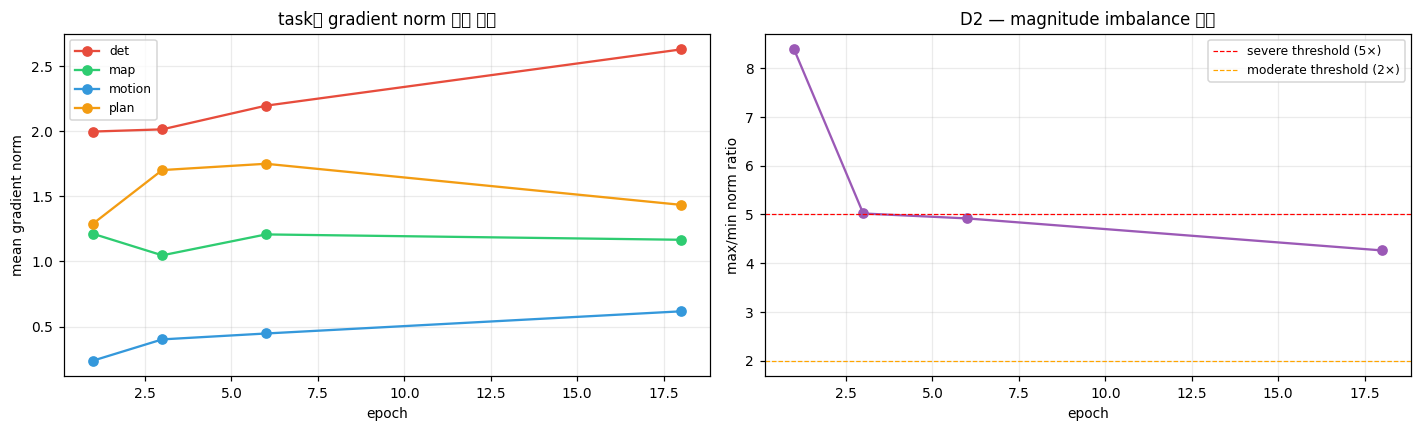

In [15]:
nd = load_norm_dynamics()
slopes, nsi, cube = load_magnitude_dynamics()

# 1. task별 norm trajectory (왼쪽) + max/min ratio 진화 (오른쪽)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
for t, g in nd.groupby('task'):
    ax.plot(g.epoch, g.mean_norm, marker='o',
            color=TASK_COLORS.get(t, '#444'), label=t)
ax.set_xlabel('epoch'); ax.set_ylabel('mean gradient norm')
ax.set_title('task별 gradient norm 시간 변화')
ax.legend(fontsize=8)

ax = axes[1]
ratios = nd.groupby('epoch').apply(
    lambda g: g.mean_norm.max() / g.mean_norm.min()).rename('ratio').reset_index()
ax.plot(ratios.epoch, ratios.ratio, marker='o', color='#9b59b6')
ax.axhline(5.0, color='red', ls='--', lw=0.8, label='severe threshold (5×)')
ax.axhline(2.0, color='orange', ls='--', lw=0.8, label='moderate threshold (2×)')
ax.set_xlabel('epoch'); ax.set_ylabel('max/min norm ratio')
ax.set_title('D2 — magnitude imbalance 진화')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


In [16]:
# slope 표 + non-stationarity index
print('D4 — task별 mean_norm vs epoch linear regression (slope, R²):')
print(slopes.to_string(index=False))
print()
print('Non-stationarity index — pairwise ratio의 epoch 간 CV:')
print(nsi.sort_values('cv', ascending=False).to_string(index=False))


D4 — task별 mean_norm vs epoch linear regression (slope, R²):
   task     slope  intercept        r2
    det  0.038316   1.939478  0.989503
    map  0.000925   1.151182  0.008382
 motion  0.018977   0.292835  0.862727
   plan -0.002962   1.564005  0.010643

Non-stationarity index — pairwise ratio의 epoch 간 CV:
 task_a  task_b        cv
    map  motion  0.452790
 motion    plan  0.385482
    det  motion  0.328772
    det    plan  0.204027
    map    plan  0.186244
    det     map  0.133448
    det     ego       NaN
    map     ego       NaN
 motion     ego       NaN
    ego    plan       NaN


/tmp/ipykernel_2219390/1792985344.py:21: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  fig.colorbar(im, ax=axes[0].tolist(), shrink=0.7, label='row/col norm ratio')
/tmp/ipykernel_2219390/1792985344.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/1792985344.py:23: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/1792985344.py:23: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/1792985344.py:23: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/1792985344.py:23: UserWarning:

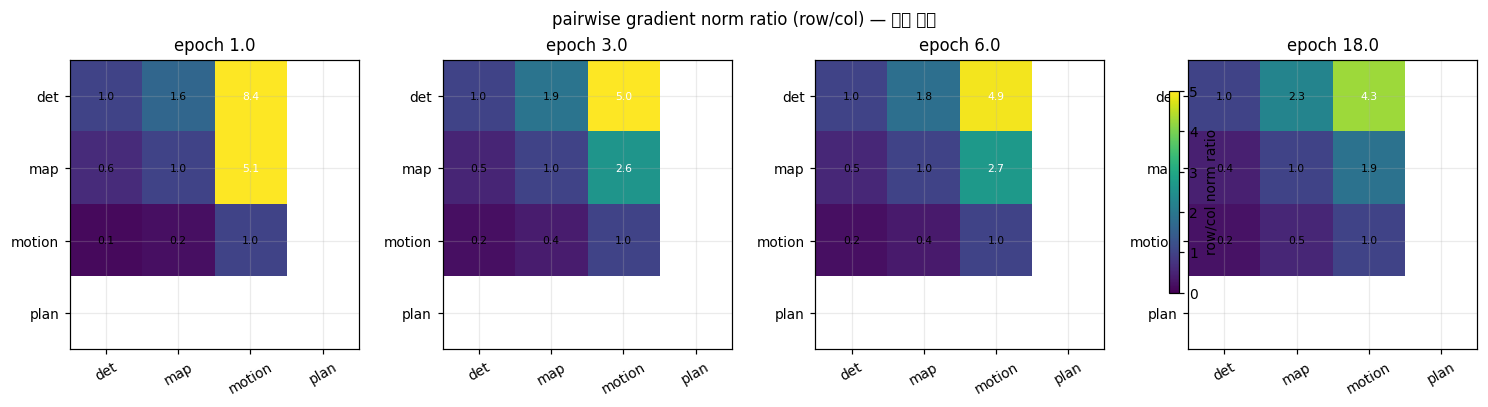

In [17]:
# pairwise norm ratio cube heatmap evolution — task pair마다 epoch 따라 ratio 어떻게 변하는지
if cube is not None:
    n_eps = cube.shape[2]
    epochs = sorted(nd.epoch.unique()) if not nd.empty else list(range(n_eps))
    fig, axes = plt.subplots(1, n_eps, figsize=(3.4 * n_eps, 3.4), squeeze=False)
    vmax = np.nanpercentile(cube, 95) if np.isfinite(cube).any() else 1.0
    tasks_present = [t for t in TASKS if t in nd.task.unique()] if not nd.empty else TASKS
    for k in range(n_eps):
        ax = axes[0, k]
        im = ax.imshow(cube[:len(tasks_present), :len(tasks_present), k],
                       cmap='viridis', vmin=0, vmax=vmax)
        ax.set_xticks(range(len(tasks_present))); ax.set_xticklabels(tasks_present, rotation=30)
        ax.set_yticks(range(len(tasks_present))); ax.set_yticklabels(tasks_present)
        ax.set_title(f'epoch {epochs[k]}')
        for i in range(len(tasks_present)):
            for j in range(len(tasks_present)):
                v = cube[i, j, k]
                if np.isfinite(v):
                    ax.text(j, i, f'{v:.1f}', ha='center', va='center',
                             fontsize=7, color='white' if v > vmax * 0.5 else 'black')
    fig.colorbar(im, ax=axes[0].tolist(), shrink=0.7, label='row/col norm ratio')
    fig.suptitle('pairwise gradient norm ratio (row/col) — 학습 진행')
    plt.tight_layout(); plt.show()


## 10. α-sensitivity sweep (Phase 1 #9) — motion source

### 왜 이 검정이 필요한가

§2의 raw variant에서 motion 대각선이 양수 (자기 step에 자기 loss 증가). 이게 step-too-large 문제인지, 아니면 freeze 안 된 stochastic source 잔존인지 분리 필요.

### 측정

motion source에 대해 4개 α (1e-4 / 5e-4 / 1e-3 / 5e-3) 모두 다시 probe 실행. **diag>0 violation 비율을 α 함수로 plot**.

### 해석

- α 줄이면 violation 줄어듦 → step-too-large. 더 작은 α 사용하면 됨.
- α 무관하게 violation 지속 → **freeze 안 된 stochastic source** 잔존. R6 audit 필요.

### 이번 실행에서 (R6 fires)

| α | raw | normalized |
|---|---|---|
| 1e-4 | 0.87 | **0.66** |
| 5e-4 | 1.00 | 0.89 |
| 1e-3 | 1.00 | 0.94 |
| 5e-3 | 1.00 | 1.00 |

α=1e-4 (1000배 줄였음) 에서도 normalized variant 66% violation. **R6 fires** — motion 코드 path에 frozen 안 된 stochastic source 잔존. 가설 분리 실험 진행 중 (fp32 sweep, L2 loss variant).


alpha sweep rows: 32
    alpha     variant source_task target_task    n  diag_violation_rate  \
0  0.0001         raw      motion         det  100                  NaN   
1  0.0001         raw      motion         map  100                  NaN   
2  0.0001         raw      motion      motion  100                 0.87   
3  0.0001         raw      motion        plan  100                  NaN   
4  0.0001  normalized      motion         det  100                  NaN   
5  0.0001  normalized      motion         map  100                  NaN   
6  0.0001  normalized      motion      motion  100                 0.66   
7  0.0001  normalized      motion        plan  100                  NaN   
8  0.0005         raw      motion         det  100                  NaN   
9  0.0005         raw      motion         map  100                  NaN   

   mean_delta  mean_delta_ci_lo  mean_delta_ci_hi  
0   -0.006283         -0.013359         -0.003387  
1    0.000052         -0.001112          0.000802

/tmp/ipykernel_2219390/1880112625.py:30: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/1880112625.py:30: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/1880112625.py:30: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/1880112625.py:30: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from current font.
  plt.tight_layout(); plt.show()
/home/yongjae/miniconda3/envs/hipad/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/yongjae/miniconda3/envs/hipad/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from current font.
  fig.c

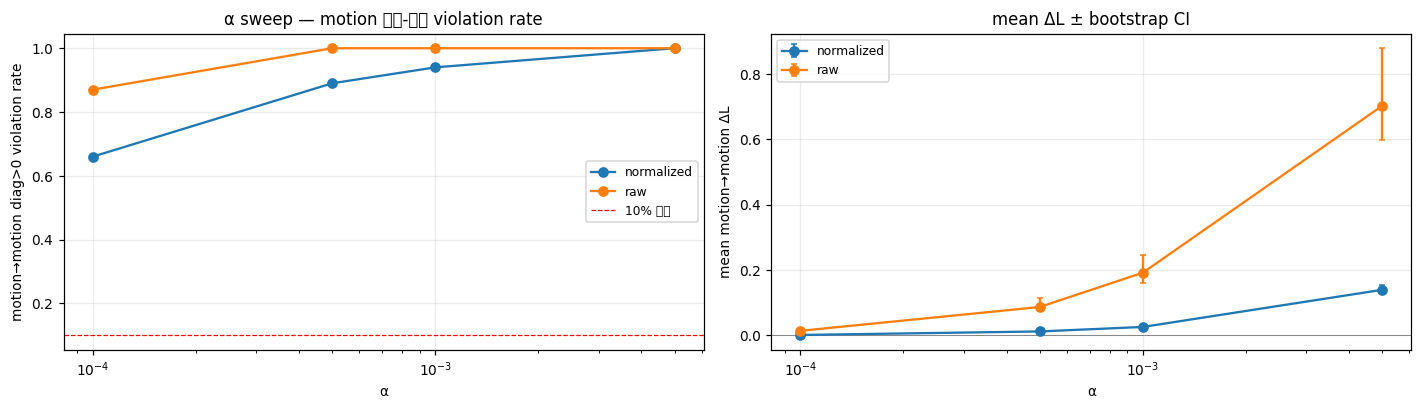

In [18]:
sweep = load_alpha_sweep(ckpt='1ep')
print(f'alpha sweep rows: {len(sweep)}')
print(sweep.head(10))

diag = sweep[sweep.source_task == sweep.target_task].copy()

# violation rate vs α + mean delta vs α (CI 포함)
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
ax = axes[0]
for variant, g in diag.groupby('variant'):
    g = g.sort_values('alpha')
    ax.plot(g.alpha, g.diag_violation_rate, marker='o', label=variant)
ax.set_xscale('log')
ax.set_xlabel('α'); ax.set_ylabel('motion→motion diag>0 violation rate')
ax.set_title('α sweep — motion 자기-자기 violation rate')
ax.axhline(0.1, color='red', ls='--', lw=0.8, label='10% 임계')
ax.legend(fontsize=8)

ax = axes[1]
for variant, g in diag.groupby('variant'):
    g = g.sort_values('alpha')
    ax.errorbar(g.alpha, g.mean_delta,
                yerr=[g.mean_delta - g.mean_delta_ci_lo, g.mean_delta_ci_hi - g.mean_delta],
                marker='o', capsize=2, label=variant)
ax.set_xscale('log')
ax.set_xlabel('α'); ax.set_ylabel('mean motion→motion ΔL')
ax.axhline(0, color='gray', lw=0.6)
ax.set_title('mean ΔL ± bootstrap CI')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


/tmp/ipykernel_2219390/4126155785.py:15: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/4126155785.py:15: UserWarning: Glyph 45796 (\N{HANGUL SYLLABLE DA}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/4126155785.py:15: UserWarning: Glyph 47480 (\N{HANGUL SYLLABLE REUN}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/4126155785.py:15: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/4126155785.py:15: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/4126155785.py:15: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/4126155785.py:15: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) 

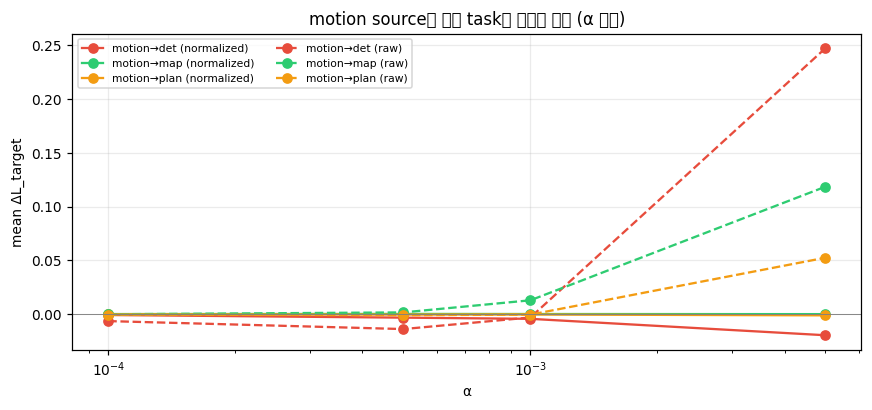

In [19]:
# motion source가 다른 task (det/map/plan)에 미치는 영향이 α에 따라 어떻게 변하는지
off = sweep[(sweep.source_task == 'motion') & (sweep.target_task != 'motion')]
fig, ax = plt.subplots(figsize=(8, 3.8))
for variant, g_v in off.groupby('variant'):
    for tgt, g in g_v.groupby('target_task'):
        g = g.sort_values('alpha')
        ax.plot(g.alpha, g.mean_delta, marker='o',
                color=TASK_COLORS.get(tgt, '#444'),
                ls='-' if variant == 'normalized' else '--',
                label=f'motion→{tgt} ({variant})')
ax.set_xscale('log'); ax.set_xlabel('α'); ax.set_ylabel('mean ΔL_target')
ax.axhline(0, color='gray', lw=0.6)
ax.set_title('motion source가 다른 task에 미치는 영향 (α 변화)')
ax.legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()


## 11. M6 dynamics — cos / helpful_ratio 시계열

### 산출물

| 파일 | 내용 |
|---|---|
| `cos_dynamics.csv` | (epoch, pair, group) → mean_cos, conflict_ratio |
| `helpful_dynamics.csv` | (epoch, source→target) → helpful_ratio |
| `norm_dynamics.csv` | (epoch, task) → mean_norm |

### helpful_ratio 정의

100 batch 중 source의 step이 **target loss를 감소시킨 비율**. 0.5 = random, 1.0 = 항상 도움.

### 그래프 읽는 법

- helpful_ratio heatmap: row = source, col = target. 초록(높음) = 도움, 빨강(낮음) = 해.
- 같은 task(self-loop, 대각선)는 1.0이어야 정상 (자기 step은 자기에 항상 도움)
- 행이 모두 0이면 그 source는 어떤 step도 의미 있는 도움 안 됨

### 이번 실행에서 주목할 패턴

- **`*→motion` row 모두 0.0** — 어떤 task의 step도 motion loss를 한 번도 감소시키지 못함.
- 결합: motion gradient norm 0.24 (1/8), motion 자기-자기 diag>0, *→motion helpful=0
- → motion은 **loss landscape가 매우 평평** 또는 **saddle 근처** 가능성 강함


In [20]:
for fname in ['cos_dynamics.csv', 'helpful_dynamics.csv']:
    p = RESULTS / 'dynamics' / fname
    if not p.exists():
        continue
    df = pd.read_csv(p)
    print(f'=== {fname} ({len(df)} rows) ===')
    print(df.head())
    print()


=== cos_dynamics.csv (1344 rows) ===
   epoch        pair            group  mean_cos  conflict_ratio
0    1.0  map|motion  backbone_layer1  0.028898            0.42
1    1.0  map|motion  backbone_layer2  0.031943            0.42
2    1.0  map|motion  backbone_layer3  0.019693            0.38
3    1.0  map|motion  backbone_layer4  0.015860            0.31
4    1.0  map|motion    backbone_stem  0.060581            0.43

=== helpful_dynamics.csv (48 rows) ===
   epoch        pair  helpful_ratio
0    1.0     det→map           0.22
1    1.0  det→motion           0.00
2    1.0    det→plan           0.53
3    1.0     map→det           0.41
4    1.0  map→motion           0.00



/tmp/ipykernel_2219390/4180104668.py:24: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  fig.colorbar(im, ax=axes.tolist(), shrink=0.7)
/tmp/ipykernel_2219390/4180104668.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/4180104668.py:25: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/4180104668.py:25: UserWarning: Glyph 47484 (\N{HANGUL SYLLABLE REUL}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/4180104668.py:25: UserWarning: Glyph 51460 (\N{HANGUL SYLLABLE JUL}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2219390/4180104668.py:25: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE 

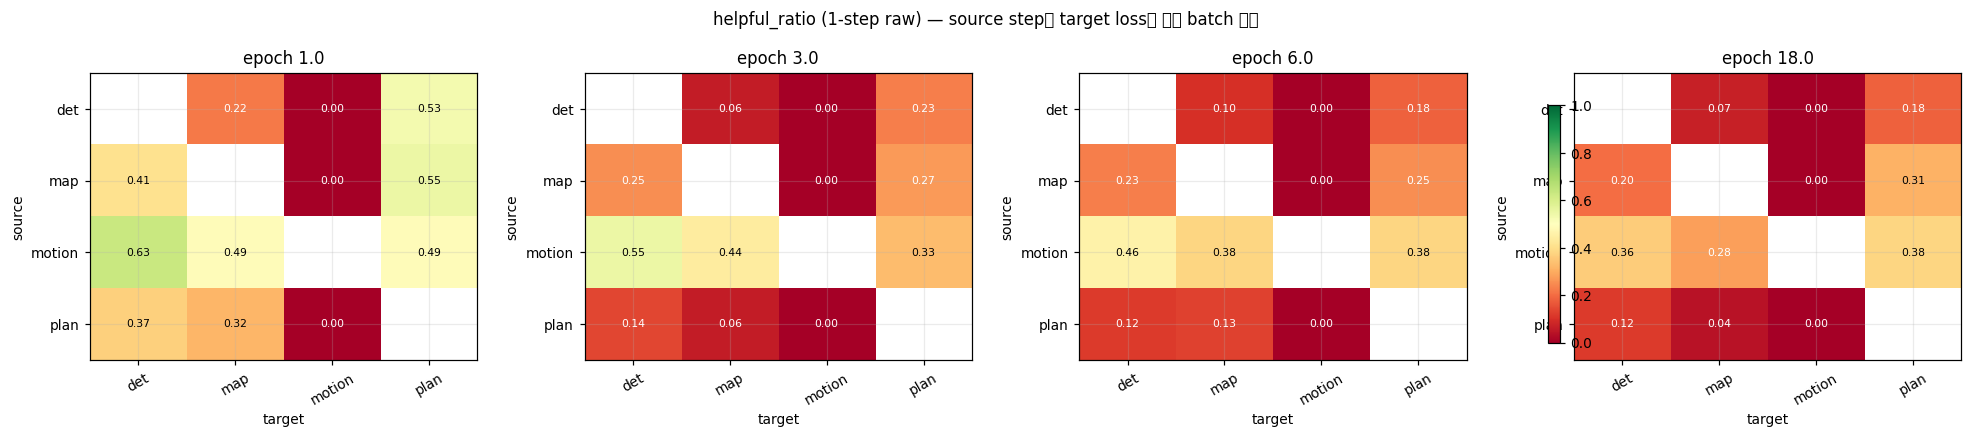

In [21]:
# helpful_ratio heatmap을 ckpt별로
help_p = RESULTS / 'dynamics' / 'helpful_dynamics.csv'
if help_p.exists():
    h = pd.read_csv(help_p)
    h[['source', 'target']] = h.pair.str.extract(r'(\w+)→(\w+)')
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    for ax, ep in zip(axes, sorted(h.epoch.unique())):
        sub = h[h.epoch == ep]
        pv = sub.pivot_table(index='source', columns='target',
                              values='helpful_ratio', aggfunc='mean').reindex(
                                index=TASKS, columns=TASKS)
        im = ax.imshow(pv.values, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
        ax.set_xticks(range(len(TASKS))); ax.set_xticklabels(TASKS, rotation=30)
        ax.set_yticks(range(len(TASKS))); ax.set_yticklabels(TASKS)
        for i in range(len(TASKS)):
            for j in range(len(TASKS)):
                v = pv.values[i, j]
                if np.isfinite(v):
                    ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7,
                             color='white' if v < 0.3 or v > 0.7 else 'black')
        ax.set_title(f'epoch {ep}')
        ax.set_xlabel('target'); ax.set_ylabel('source')
    fig.suptitle('helpful_ratio (1-step raw) — source step이 target loss를 줄인 batch 비율')
    fig.colorbar(im, ax=axes.tolist(), shrink=0.7)
    plt.tight_layout(); plt.show()


## 12. diagonal sanity check — motion violation 패턴 정밀

### 정상 동작 기준

- source = target 이면 ΔL < 0 이어야 함 (자기 step은 자기 loss 감소)
- 양수면 **probe 메커니즘에 stochastic source 잔존** 또는 **step-too-large**

### 두 표 출력

1. **mean ΔL by (ckpt × source × variant)**: 평균값. 음수여야 정상.
2. **violation rate**: 100 batch 중 ΔL > 0 인 비율. 0에 가까워야 정상.

### 이번 실행에서

normalized variant:
| ckpt | det | map | motion | plan |
|---|---|---|---|---|
| 1ep | 0.00 | 0.02 | **0.92** | 0.00 |
| 18ep | 0.02 | 0.00 | **0.82** | 0.00 |

raw variant:
| ckpt | det | map | motion | plan |
|---|---|---|---|---|
| 1ep | 0.48 | 0.01 | 1.00 | 0.35 |
| 18ep | **0.82** | 0.10 | 0.99 | **0.87** |

해석:
- **normalized에서는 motion만의 문제** (다른 task는 거의 0%)
- **raw에서는 학습 후반 모든 task가 violation 심각** (det 82%, plan 87%)
- → raw variant는 step-too-large가 main cause. normalized는 motion에 한정된 freeze 문제.

### 다음 단계

- **R6 freeze audit**: motion code path 추적 (fp16 vs fp32, L1 vs L2 loss 실험 진행 중)
- **메인 보고서는 normalized만 사용** 권장 (raw는 부록으로 강등)


In [22]:
diag = probe_long[(probe_long.source_task == probe_long.target_task)
                  & (probe_long.layer == '_all') & (probe_long.steps == 1)]

for variant in ['normalized', 'raw']:
    sub = diag[diag.variant == variant]
    pv = (sub.groupby(['ckpt', 'source_task'], observed=True)['delta']
              .mean().unstack('source_task').reindex(columns=TASKS))
    print(f'\n=== Diagonal mean ΔL ({variant}) ===')
    print(pv)



=== Diagonal mean ΔL (normalized) ===
source_task       det       map    motion      plan
ckpt                                               
1ep         -0.043141 -0.020374  0.024257 -0.028442
3ep         -0.043935 -0.017701  0.029475 -0.036366
6ep         -0.041315 -0.017827  0.027776 -0.030199
18ep        -0.043374 -0.016250  0.022054 -0.026276

=== Diagonal mean ΔL (raw) ===
source_task       det       map    motion      plan
ckpt                                               
1ep          0.122486 -0.232725  0.179850 -0.007876
3ep          0.151640 -0.119959  0.248303  0.797386
6ep          0.304300 -0.139584  0.263604  0.655915
18ep         0.952618 -0.101742  0.251604  0.602715


자기-자기 step 후 self-loss 증가한 batch 비율:
source_task       det   map  motion  plan
ckpt variant                             
1ep  normalized  0.00  0.02    0.92  0.00
     raw         0.48  0.01    1.00  0.35
3ep  normalized  0.01  0.01    0.86  0.00
     raw         0.51  0.09    0.96  0.69
6ep  normalized  0.00  0.00    0.87  0.00
     raw         0.63  0.09    0.99  0.77
18ep normalized  0.02  0.00    0.82  0.00
     raw         0.82  0.10    0.99  0.87


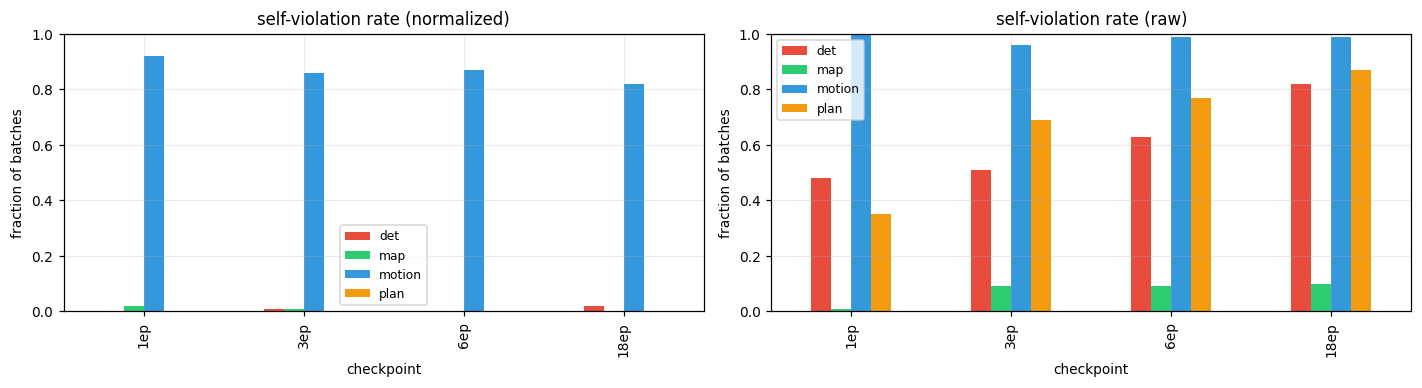

In [23]:
# violation rate를 막대로 시각화 — variant 두 개 나란히
viol = (diag.assign(violates=lambda d: d.delta > 0)
            .groupby(['ckpt', 'source_task', 'variant'], observed=True)['violates']
            .mean().unstack('source_task').reindex(columns=TASKS))
print('자기-자기 step 후 self-loss 증가한 batch 비율:')
print(viol)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
for ax, variant in zip(axes, ['normalized', 'raw']):
    sub = viol.xs(variant, level='variant')
    sub.plot(kind='bar', ax=ax, color=[TASK_COLORS.get(t, '#444') for t in sub.columns])
    ax.set_title(f'self-violation rate ({variant})')
    ax.set_ylabel('fraction of batches'); ax.set_xlabel('checkpoint')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
